# Nyul Normalization Sanity Check
Quick checks for Nyul-normalized NIfTI outputs. Configure paths in the first code cell.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

# ---- Configure ----
# Root folder with Nyul-normalized outputs
out_root = Path("/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized")
# Optional: folder with pre-normalization inputs (set to None to skip comparison)
before_dir = Path("/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3_1NiftiNyulReady/trainingforcalc/MR")
# File pattern for NIfTI files
pattern = "*.nii*"
# How many files to inspect in detail (set to None to use all)
max_files = None


In [2]:
assert out_root.exists(), f"Output root not found: {out_root}"
mr_dirs = sorted(out_root.glob("*/MR"))
files = []
for d in mr_dirs:
    files.extend(sorted(d.glob(pattern)))

print(f"Found {len(mr_dirs)} MR folders and {len(files)} files under {out_root}")
if max_files is not None:
    files = files[:max_files]
files


Found 175 MR folders and 175 files under /local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized


[PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA005/MR/AB_1ABA005_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA009/MR/AB_1ABA009_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA011/MR/AB_1ABA011_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA012/MR/AB_1ABA012_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA014/MR/AB_1ABA014_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/experiment2/33nyul/3normalized/AB_1ABA018/MR/AB_1ABA018_MR_cp256.nii.gz'),
 PosixPath('/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocess

In [3]:
def load_data(path: Path):
    img = nib.load(str(path))
    data = img.get_fdata()
    return img, data

rows = []
for f in files:
    _, data = load_data(f)
    rows.append({
        'file': f.name,
        'min': float(np.nanmin(data)),
        'max': float(np.nanmax(data)),
        'mean': float(np.nanmean(data)),
        'std': float(np.nanstd(data)),
        'nan': bool(np.isnan(data).any()),
        'inf': bool(np.isinf(data).any()),
    })

df = pd.DataFrame(rows)
df

,file,min,max,mean,std,nan,inf
0,AB_1ABA005_MR_cp256.nii.gz,0.0,1.0,0.123933,0.242069,False,False
1,AB_1ABA009_MR_cp256.nii.gz,0.0,1.0,0.095786,0.219497,False,False
2,AB_1ABA011_MR_cp256.nii.gz,0.0,1.0,0.136930,0.250644,False,False
3,AB_1ABA012_MR_cp256.nii.gz,0.0,1.0,0.152350,0.259403,False,False
4,AB_1ABA014_MR_cp256.nii.gz,0.0,1.0,0.136060,0.250143,False,False
...,...,...,...,...,...,...,...
170,AB_1ABC118_MR_cp256.nii.gz,0.0,1.0,0.071185,0.194638,False,False
171,AB_1ABC121_MR_cp256.nii.gz,0.0,1.0,0.109037,0.231166,False,False
172,AB_1ABC122_MR_cp256.nii.gz,0.0,1.0,0.143604,0.256784,False,False
173,AB_1ABC127_MR_cp256.nii.gz,0.0,1.0,0.118682,0.241783,False,False


In [4]:
# Check expected range (0..1)
range_ok = (df['min'] >= -1e-6) & (df['max'] <= 1 + 1e-6)
print('Range check (0..1) passed for all:', range_ok.all())
df.loc[~range_ok]

Range check (0..1) passed for all: True


,file,min,max,mean,std,nan,inf


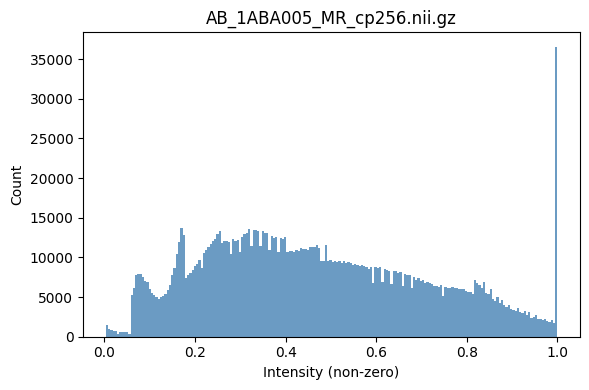

In [5]:
# Histogram for a sample file (exclude zeros)
if files:
    _, data = load_data(files[0])
    vals = data[np.isfinite(data)]
    vals = vals[vals != 0]
    plt.figure(figsize=(6, 4))
    plt.hist(vals.ravel(), bins=200, color='steelblue', alpha=0.8)
    plt.title(files[0].name)
    plt.xlabel('Intensity (non-zero)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


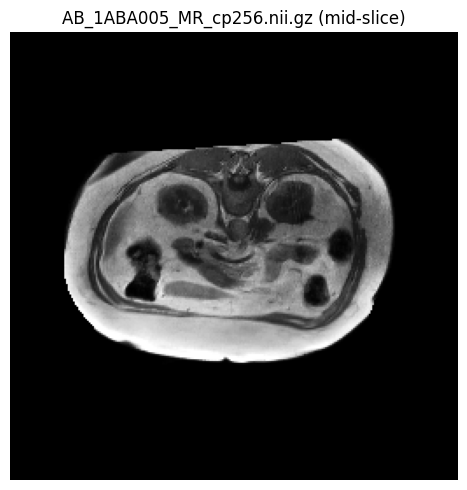

In [13]:
# Quick mid-slice visualization for one file (auto window)
if files:
    _, data = load_data(files[0])
    z = data.shape[2] // 2 if data.ndim == 3 else data.shape[0] // 2
    slice_ = data[:, :, z] if data.ndim == 3 else data[z]
    vals = slice_[np.isfinite(slice_)]
    vals = vals[vals != 0]
    vmin, vmax = np.percentile(vals, [1, 99]) if vals.size else (0, 1)
    plt.figure(figsize=(5, 5))
    plt.imshow(slice_.T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    plt.title(f"{files[0].name} (mid-slice)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [7]:
# Optional before/after comparison if before_dir is provided
if before_dir is not None:
    assert before_dir.exists(), f"Before dir not found: {before_dir}"
    def norm_key(p: Path) -> str:
        # Match files like 1ABA005_MR_nyul.nii.gz to 1ABA005_MR.nii.gz
        name = p.name
        for ext in ('.nii.gz', '.nii'):
            if name.endswith(ext):
                name = name[:-len(ext)]
                break
        if name.endswith('_nyul'):
            name = name[:-5]
        return name

    before_files = {norm_key(p): p for p in before_dir.glob(pattern)}
    common = [f for f in files if norm_key(f) in before_files]
    print(f"Found {len(common)} matching files in before_dir")

    if common:
        after_path = common[0]
        before_path = before_files[norm_key(after_path)]
        _, before = load_data(before_path)
        _, after = load_data(after_path)

        # Plot histograms separately (exclude zeros)
        before_vals = before[np.isfinite(before)]
        after_vals = after[np.isfinite(after)]
        before_vals = before_vals[before_vals != 0]
        after_vals = after_vals[after_vals != 0]

        plt.figure(figsize=(6, 4))
        plt.hist(before_vals.ravel(), bins=200, alpha=0.8, color='gray')
        plt.title(f"Before: {before_path.name}")
        plt.xlabel('Intensity (non-zero)')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(after_vals.ravel(), bins=200, alpha=0.8, color='steelblue')
        plt.title(f"After: {after_path.name}")
        plt.xlabel('Intensity (non-zero)')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

        # Visual compare mid-slice with auto windowing
        z = after.shape[2] // 2 if after.ndim == 3 else after.shape[0] // 2
        before_slice = before[:, :, z] if before.ndim == 3 else before[z]
        after_slice = after[:, :, z] if after.ndim == 3 else after[z]
        def auto_window(slice_):
            vals = slice_[np.isfinite(slice_)]
            vals = vals[vals != 0]
            return np.percentile(vals, [1, 99]) if vals.size else (0, 1)
        bmin, bmax = auto_window(before_slice)
        amin, amax = auto_window(after_slice)
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(before_slice.T, cmap='gray', origin='lower', vmin=bmin, vmax=bmax)
        axes[0].set_title('Before')
        axes[0].axis('off')
        axes[1].imshow(after_slice.T, cmap='gray', origin='lower', vmin=amin, vmax=amax)
        axes[1].set_title('After')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()


Found 0 matching files in before_dir
